récupérer le dataset du titanic

In [2]:
# dataset récupérer nos données

import seaborn as sns
import numpy as np

titanic = sns.load_dataset("titanic")

titanic.shape # numpy (891, 15)
titanic.head() # pandas

titanic = titanic[["survived" , "pclass" , "sex" , "age" ]]

# transformer male en 0 et female en 1
# les modèles ne comprennent pas les textes
titanic["sex"] = titanic["sex"].map({ 'male' : 0 , 'female' : 1 })

titanic.dropna(axis=0, inplace=True)

titanic.describe()

y = titanic["survived"]
y = y.values.reshape(-1,1) # transformer les dimensions du vecteur
                           # (714,) => (714,1)
                           # Eviter les opérations de Broadcasting 

X = titanic.drop( ["survived"], axis=1 ) # (714, 3)

In [3]:
from sklearn.model_selection import train_test_split

print(X.shape, y.shape)

X_train,X_test, y_train  , y_test = train_test_split(X,y, test_size=0.2)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(714, 3) (714, 1)
(571, 3) (143, 3) (571, 1) (143, 1)


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

hyper_params = {
    'n_neighbors' : np.arange(1,50, 1),
    'metric' : ['euclidean', 'manhattan', "minkowski"]
}

# grid qui va nous retourner la meilleur valeur parmis les hyper_params

grid = GridSearchCV(
    KNeighborsClassifier(),
    hyper_params ,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
# KNeighborsClassifier(metric='manhattan', n_neighbors=np.int64(13))

model = grid.best_estimator_


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

{'metric': 'manhattan', 'n_neighbors': np.int64(7)}


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

In [5]:
# évaluer le modèle

model.score( X_test , y_test )

0.8111888111888111

[[77  9]
 [18 39]]


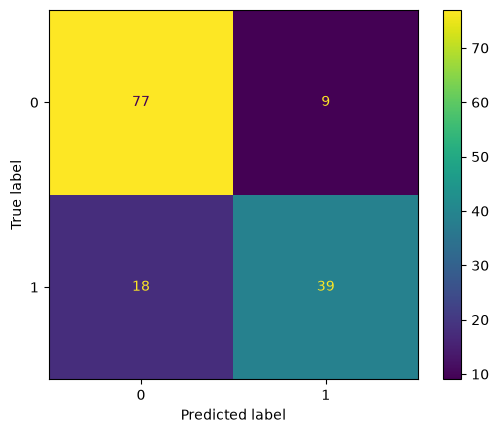

In [6]:
# évaluer les erreurs que fait notre modele

from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

result = confusion_matrix(y_test , model.predict(X_test))

print(result)

disp = ConfusionMatrixDisplay(confusion_matrix=result,
                              display_labels=model.classes_)

disp.plot()
plt.savefig("sk-titanic-correction.png")